In [1]:
import tensorflow as tf
import optuna
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

In [2]:
# ============================================
# CONFIGURATION
# ===========================================

IMG_HEIGHT = 128
IMG_WIDTH = 128

BATCH_SIZE=32


In [3]:
# ============================================
# IMAGE DATA GENERATOR
# ===========================================

train_datagen = ImageDataGenerator(
  rescale=1./255,
  rotation_range=20,
  zoom_range=0.2,
  horizontal_flip=True
)

validation_datagen = ImageDataGenerator(
  rescale=1./255,
)


In [4]:
# ============================================
# LOAD IMAGE
# ===========================================

train_dir = "dataset/train"
validation_dir = "dataset/val"
test_dir = "dataset/test"

train_data = train_datagen.flow_from_directory(
  train_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='binary' 
)

validation_data = validation_datagen.flow_from_directory(
  validation_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='binary' 
)

test_data = validation_datagen.flow_from_directory(
  test_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='binary',
  shuffle=False
)

print(train_data.class_indices)




Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
{'no': 0, 'yes': 1}


In [7]:
# ============================================
# TUNING WITH BAYESIAN
# ===========================================

def objective(trial: optuna.Trial):
  # feature_map layer 1
  features_1 = trial.suggest_categorical(
    "features_1",
    [32, 64]
  )

  # features_map layer 2 
  features_2 = trial.suggest_categorical(
    "features_2",
    [64, 128],
  )

  # fully_connected newuron
  dense_unit_1 = trial.suggest_int(
    "dense_unit_1",
    64, 
    256,
    step=64
  )

  dense_unit_2 = trial.suggest_int(
    "dense_unit_2",
    64, 
    256,
    step=64
  )

  # dropout
  dropout_rate_1 = trial.suggest_float(
    "dropout_rate_1",
    0.2, 
    0.5
  )
  
  dropout_rate_2 = trial.suggest_float(
    "dropout_rate_2",
    0.2, 
    0.5
  )

  # learning rate
  learning_rate = trial.suggest_float(
    "learning_rate",
    1e-4, 
    1e-2,
    log=True
  ) 

  # optimizer
  optimizer = trial.suggest_categorical(
    "optimizer",
    ["adam", "sgd"]
  )

  epoch = trial.suggest_int(
    "epoch",
    10, 
    20,
    step=5
  )

  # ============================================
  # BUILD MODEL
  # ===========================================
  model = tf.keras.Sequential([

    # CNN Layer 1
    tf.keras.layers.Conv2D(
      features_1,
      (3, 3),
      activation='relu',
      padding='same',
      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),

    # CNN layer 2
    tf.keras.layers.Conv2D(
      features_2,
      (3, 3),
      activation='relu',
      padding='same'
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),


    # flatten
    tf.keras.layers.Flatten(),


    # fully connected layer
    tf.keras.layers.Dense(
      dense_unit_1,
      activation='relu'
    ),

    tf.keras.layers.Dropout(
      dropout_rate_1,
    ),

    tf.keras.layers.Dense(
      dense_unit_2,
      activation='relu'
    ),

    tf.keras.layers.Dropout(
      dropout_rate_2,
    ),

    # output
    tf.keras.layers.Dense(
      1,
      activation='sigmoid'
    )
  ])


  # optimizer
  if optimizer == "adam":
    model_optimizer = tf.keras.optimizers.Adam(
      learning_rate=learning_rate
    )
  else:
    model_optimizer = tf.keras.optimizers.SGD(
      learning_rate = learning_rate
    )

  model.compile(
    optimizer=model_optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
  )

  #early stop
  early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

  history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=epoch,
    verbose=0,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
  )

  loss, accuracy = model.evaluate(
    test_data,
    verbose=0
  )

  return accuracy



In [8]:
# =========================================================
# CREATE OPTUNA STUDY
# =========================================================

study = optuna.create_study(
    direction='maximize'
)

# =========================================================
# START OPTIMIZATION
# =========================================================

study.optimize(
  objective,
  n_trials=20,
)

print("\nBest Hyperparameters:")
print(study.best_params)

print("\nBest Accuracy:")
print(study.best_value)


[I 2026-05-18 13:59:15,293] A new study created in memory with name: no-name-a5a345c0-4195-42fe-8e82-1b043f96c336
/opt/miniconda3/envs/machine-learning/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-05-18 13:59:37,156] Trial 0 finished with value: 0.7777777910232544 and parameters: {'features_1': 32, 'features_2': 128, 'dense_unit_1': 192, 'dense_unit_2': 192, 'dropout_rate_1': 0.45893548080754365, 'dropout_rate_2': 0.4608635078530722, 'learning_rate': 0.009530914356193455, 'optimizer': 'sgd', 'epoch': 15}. Best is trial 0 with value: 0.7777777910232544.
[I 2026-05-18 13:59:53,847] Trial 1 finished with value: 0.8518518805503845 and parameters: {'features_1': 64, 'features_2': 64, 'dense_unit_1':


Best Hyperparameters:
{'features_1': 64, 'features_2': 64, 'dense_unit_1': 256, 'dense_unit_2': 256, 'dropout_rate_1': 0.390917460267495, 'dropout_rate_2': 0.44090504925199986, 'learning_rate': 0.0002395912623138842, 'optimizer': 'adam', 'epoch': 20}

Best Accuracy:
0.8518518805503845


In [9]:
# =========================================================
# TRAIN FINAL MODEL AFTER OPTUNA OPTIMAZTION TUNING
# =========================================================
best_params = study.best_params
model = tf.keras.Sequential([
  # CNN Layer 1
  tf.keras.layers.Conv2D(
    best_params['features_1'],
    (3, 3),
    activation='relu',
    padding='same',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
  ),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),

  # CNN layer 2
  tf.keras.layers.Conv2D(
    best_params['features_2'],
    (3, 3),
    activation='relu',
    padding='same'
  ),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),


  # flatten
  tf.keras.layers.Flatten(),


  # fully connected layer
  tf.keras.layers.Dense(
    best_params['dense_unit_1'],
    activation='relu'
  ),

  tf.keras.layers.Dropout(
    best_params['dropout_rate_1'],
  ),

  tf.keras.layers.Dense(
    best_params['dense_unit_2'],
    activation='relu'
  ),

  tf.keras.layers.Dropout(
    best_params['dropout_rate_2'],
  ),

  # output
  tf.keras.layers.Dense(
    1,
    activation='sigmoid'
  )
])

# optimizer
if best_params['optimizer'] == "adam":
  model_optimizer = tf.keras.optimizers.Adam(
    learning_rate=best_params['learning_rate']
  )
else:
  model_optimizer = tf.keras.optimizers.SGD(
    learning_rate = best_params['learning_rate']
  )

model.compile(
  optimizer=model_optimizer,
  loss='binary_crossentropy',
  metrics=['accuracy'],
)

In [10]:
# =========================================================
# MODEL FIT WITH BEST PARAM
# =========================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
  train_data,
  validation_data=validation_data,
  epochs=best_params['epoch'],
  verbose=0,
  batch_size=BATCH_SIZE,
  callbacks=[early_stop]
)

In [11]:
loss, accuracy = model.evaluate(
  test_data,
  verbose=0
)
print(f"\nTest Accuracy: {accuracy}")
print(f"\nTest Loss: {loss}")


Test Accuracy: 0.8518518805503845

Test Loss: 0.44578033685684204


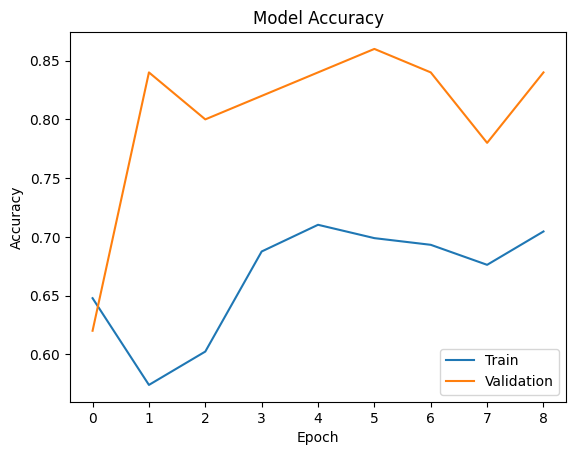

In [12]:
import matplotlib.pyplot as plt

# =========================================================
# VISUALIZATION ACCURACY
# =========================================================

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

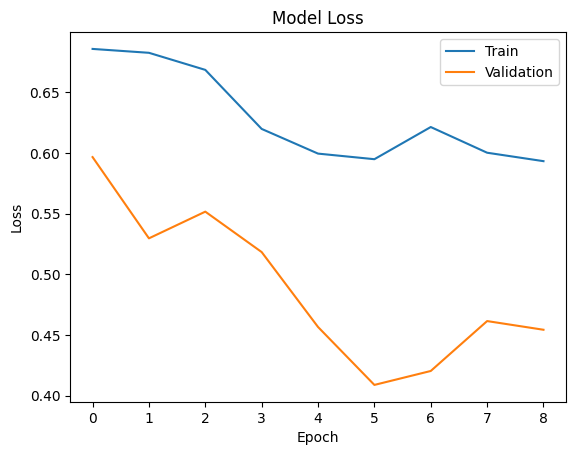

In [13]:
# =========================================================
# VISUALIZATION LOSS
# =========================================================

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [21]:
# =========================================================
# TEST SAMPLE
# =========================================================

image_path = "sample-no.jpg"
image_sample = load_img(
  image_path,
  target_size=(IMG_HEIGHT, IMG_WIDTH)
)

image_array = img_to_array(image_sample)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model.predict(image_array)

print("\nPrediction Probability:")
print(prediction)

if prediction[0][0] > 0.5:
  predicted_class = 1
else:
  predicted_class = 0

class_names = list(train_data.class_indices.keys())
print("\nPredicted Class:")
print(class_names[predicted_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Prediction Probability:
[[0.32809955]]

Predicted Class:
no


In [20]:
image_path = "sample-yes.JPG"
image_sample = load_img(
  image_path,
  target_size=(IMG_HEIGHT, IMG_WIDTH)
)

image_array = img_to_array(image_sample)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model.predict(image_array)

print("\nPrediction Probability:")
print(prediction)

if prediction[0][0] > 0.5:
  predicted_class = 1
else:
  predicted_class = 0

class_names = list(train_data.class_indices.keys())
print("\nPredicted Class:")
print(class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Prediction Probability:
[[0.7819374]]

Predicted Class:
yes
